# Analiza Rezultata: REINFORCE Vanilla vs. Baseline

**Projekat iz Reinforcement Learning-a**

Ovaj notebook analizira rezultate treninga dva algoritma:
1. **Vanilla REINFORCE** - bez baseline-a
2. **REINFORCE + Baseline** - sa Value mrežom

---

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Podešavanja za lepe grafike
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('✓ Biblioteke učitane')

✓ Biblioteke učitane


## 1. Učitavanje Podataka

Učitavamo CSV fajlove iz `logs/` foldera.

In [11]:
# Funkcija za učitavanje rezultata za sve seed-ove
def load_all_seeds(algorithm_name, seeds=[1, 2, 3]):
    """Učitava sve CSV fajlove za dati algoritam"""
    all_data = []
    
    for seed in seeds:
        filepath = f'logs/{algorithm_name}_seed{seed}.csv'
        
        if Path(filepath).exists():
            df = pd.read_csv(filepath)
            df['seed'] = seed
            df['algorithm'] = algorithm_name.replace('_', ' ').title()
            all_data.append(df)
        else:
            print(f'⚠️  Nedostaje fajl: {filepath}')
    
    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        return None

# Učitaj podatke
vanilla_df = load_all_seeds('vanilla')
baseline_df = load_all_seeds('baseline')

# Provera
if vanilla_df is not None:
    print(f'✓ Vanilla REINFORCE: {len(vanilla_df)} redova učitano')
if baseline_df is not None:
    print(f'✓ Baseline REINFORCE: {len(baseline_df)} redova učitano')

# Kombinuj sve podatke
if vanilla_df is not None and baseline_df is not None:
    all_data = pd.concat([vanilla_df, baseline_df], ignore_index=True)
    print(f'\n✓ Ukupno učitano: {len(all_data)} redova')
    print(f'Algoritmi: {all_data["algorithm"].unique()}')
else:
    print('\n❌ GREŠKA: Podaci nisu pronađeni. Da li si pokrenuo trening skripte?')

✓ Vanilla REINFORCE: 15000 redova učitano
✓ Baseline REINFORCE: 15000 redova učitano

✓ Ukupno učitano: 30000 redova
Algoritmi: <StringArray>
['Vanilla', 'Baseline']
Length: 2, dtype: str


## 2. Learning Curves (Krive Učenja)

Poredimo kako brzo svaki algoritam uči.

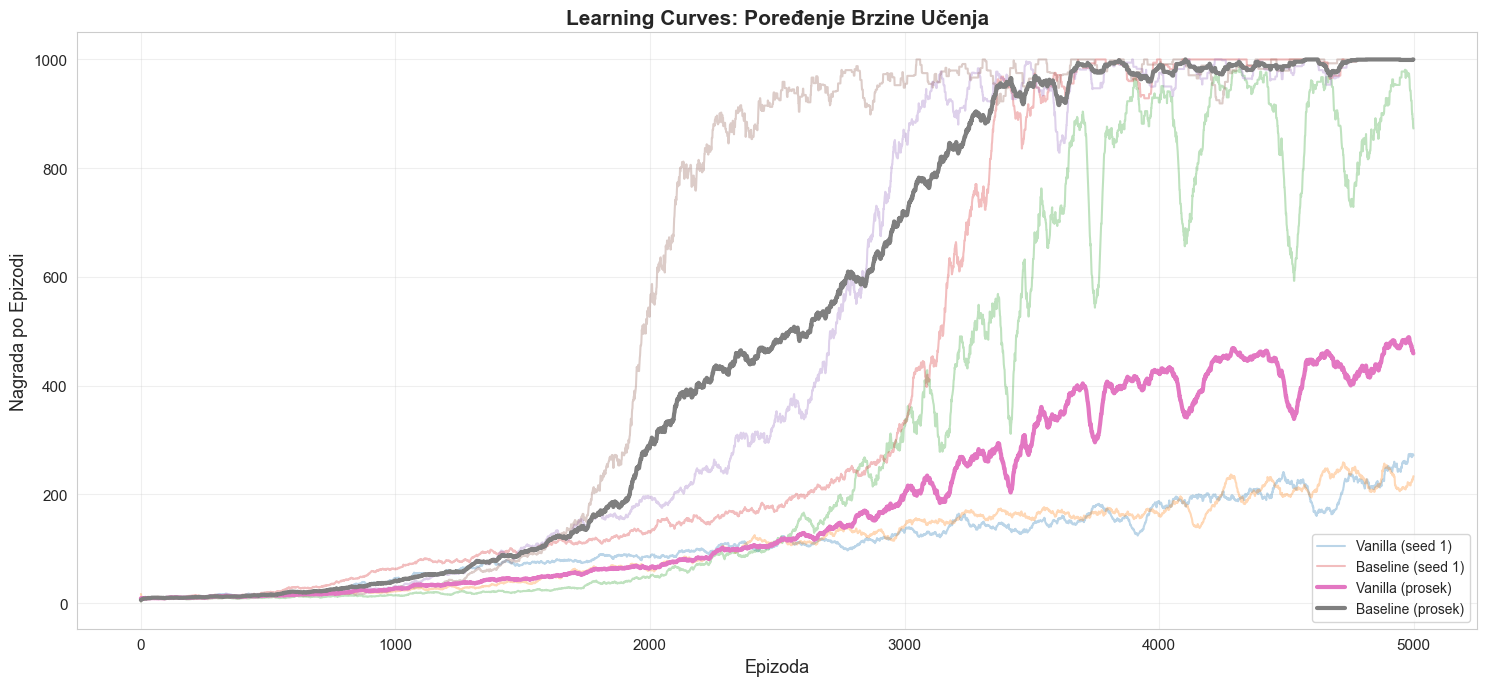

✓ Grafik sačuvan: logs/learning_curves.png


In [12]:
# Funkcija za smoothing (klizeći prosek)
def moving_average(data, window=50):
    """Izračunava klizeći prosek za glatkije krive"""
    return data.rolling(window=window, min_periods=1).mean()

plt.figure(figsize=(15, 7))

# Crtanje za svaki seed posebno (providne linije)
for algo in all_data['algorithm'].unique():
    algo_data = all_data[all_data['algorithm'] == algo]
    
    for seed in algo_data['seed'].unique():
        seed_data = algo_data[algo_data['seed'] == seed]
        smoothed = moving_average(seed_data['reward'], window=50)
        plt.plot(seed_data['episode'], smoothed, alpha=0.3, 
                label=f'{algo} (seed {seed})' if seed == 1 else '')

# Prosek svih seed-ova (debele linije)
for algo in all_data['algorithm'].unique():
    algo_data = all_data[all_data['algorithm'] == algo]
    avg_by_episode = algo_data.groupby('episode')['reward'].mean()
    smoothed_avg = moving_average(avg_by_episode, window=50)
    plt.plot(smoothed_avg.index, smoothed_avg.values, linewidth=3, label=f'{algo} (prosek)')

plt.xlabel('Epizoda', fontsize=13)
plt.ylabel('Nagrada po Epizodi', fontsize=13)
plt.title('Learning Curves: Poređenje Brzine Učenja', fontsize=15, weight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logs/learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Grafik sačuvan: logs/learning_curves.png')

## 3. Analiza Varijanse

**Hipoteza:** Baseline bi trebao da smanji varijansu (šum) tokom učenja.

Računamo varijansu nagrada između različitih seed-ova.

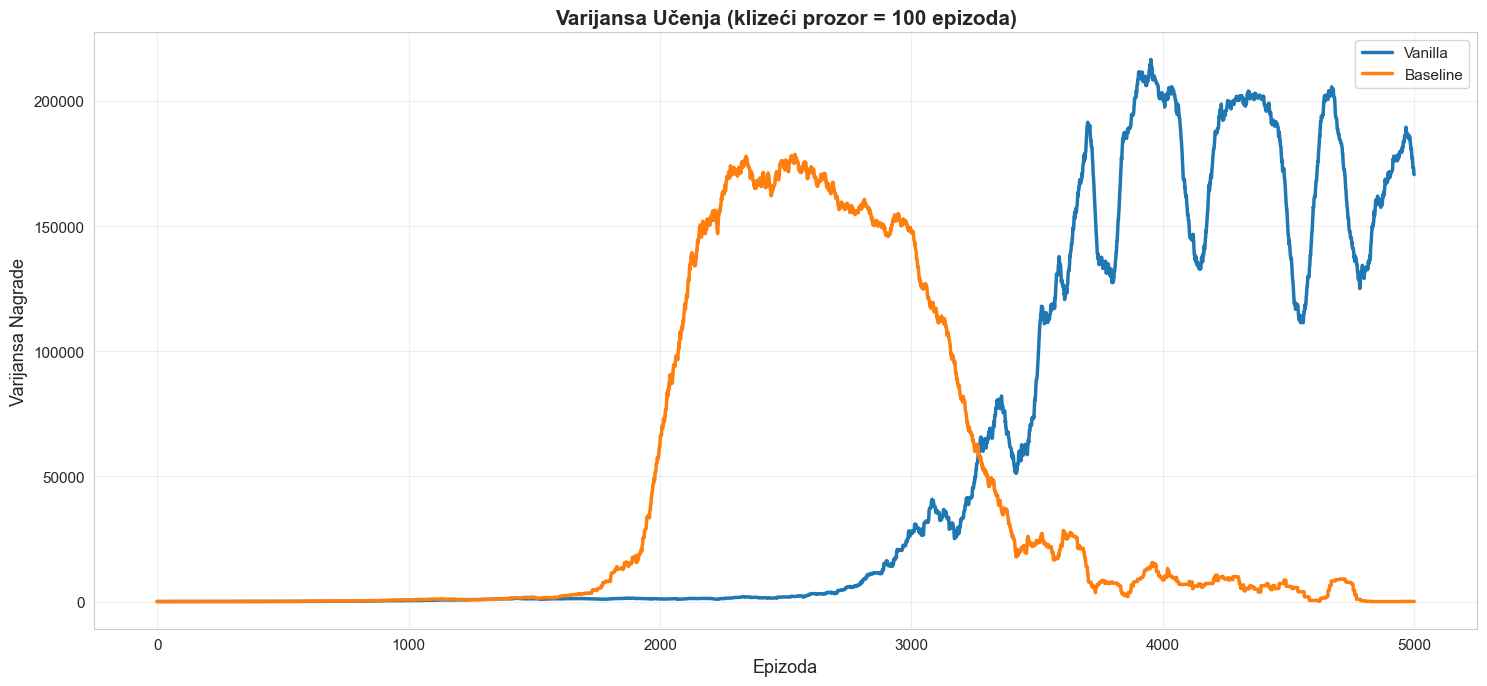

✓ Grafik sačuvan: logs/variance_analysis.png

💡 Niža kriva = stabilnije učenje


In [13]:
plt.figure(figsize=(15, 7))

window = 100  # Prozor za klizeću varijansu

for algo in all_data['algorithm'].unique():
    algo_data = all_data[all_data['algorithm'] == algo]
    
    # Varijansa nagrada po epizodi (kroz sve seed-ove)
    variance_by_episode = algo_data.groupby('episode')['reward'].var()
    smoothed_var = moving_average(variance_by_episode, window=window)
    
    plt.plot(smoothed_var.index, smoothed_var.values, linewidth=2.5, label=algo)

plt.xlabel('Epizoda', fontsize=13)
plt.ylabel('Varijansa Nagrade', fontsize=13)
plt.title(f'Varijansa Učenja (klizeći prozor = {window} epizoda)', fontsize=15, weight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logs/variance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Grafik sačuvan: logs/variance_analysis.png')
print('\n💡 Niža kriva = stabilnije učenje')

## 4. Finalne Performanse

Analiziramo poslednje epizode da vidimo koji algoritam dostiže bolje rezultate.

C:\Users\ninac\AppData\Local\Temp\ipykernel_2992\1114834944.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_data, x='algorithm', y='reward', palette='Set2')


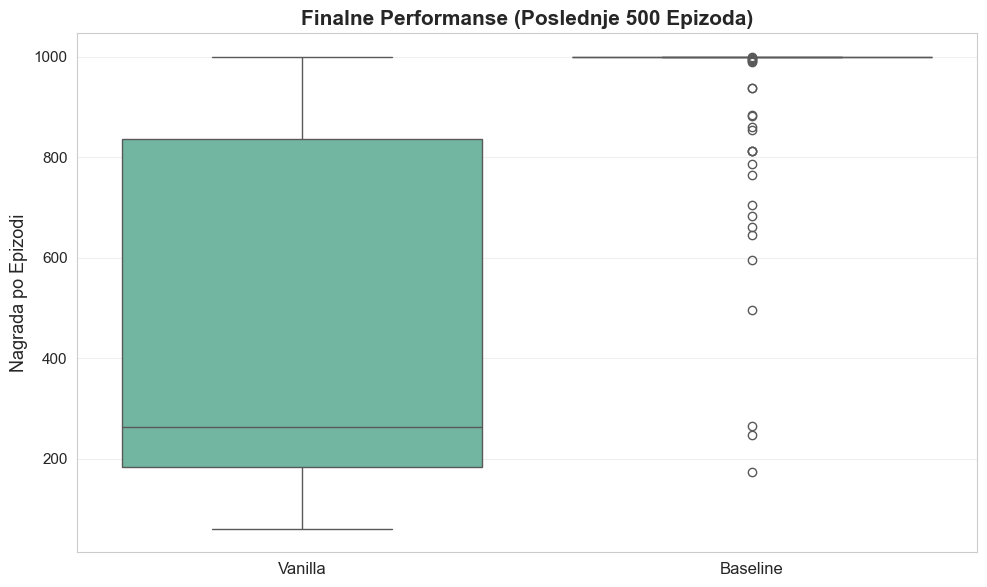

✓ Grafik sačuvan: logs/final_performance.png

📊 Statistika Finalnih Performansi:

             mean     std  min   max
algorithm                           
Baseline   995.86   43.86  174  1000
Vanilla    439.44  341.34   61  1000


In [14]:
# Uzimamo poslednjih 500 epizoda kao "finale" performanse
max_episode = all_data['episode'].max()
final_data = all_data[all_data['episode'] >= max_episode - 500]

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_data, x='algorithm', y='reward', palette='Set2')
plt.ylabel('Nagrada po Epizodi', fontsize=13)
plt.xlabel('')
plt.title('Finalne Performanse (Poslednje 500 Epizoda)', fontsize=15, weight='bold')
plt.xticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('logs/final_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Grafik sačuvan: logs/final_performance.png')

# Ispis statistike
print('\n📊 Statistika Finalnih Performansi:\n')
stats = final_data.groupby('algorithm')['reward'].agg(['mean', 'std', 'min', 'max'])
print(stats.round(2))

## 5. Robustness Test (Test sa Vetrom)

Ako si pokrenuo `main_test_robustness.py`, evo analize tih rezultata.

In [15]:
# Proveri da li postoje fajlovi za robustnost
robustness_files = list(Path('logs/').glob('robustness_*.csv'))

if len(robustness_files) > 0:
    print(f'✓ Pronađeno {len(robustness_files)} fajlova robustnosti\n')
    
    # Učitaj sve rezultate
    robustness_data = []
    for file in robustness_files:
        df = pd.read_csv(file)
        algo_name = file.stem.replace('robustness_', '').replace('_seed1', '')
        df['algorithm'] = algo_name.replace('_', ' ').title()
        robustness_data.append(df)
    
    robustness_df = pd.concat(robustness_data, ignore_index=True)
    
    # Grafik
    plt.figure(figsize=(12, 6))
    
    for algo in robustness_df['algorithm'].unique():
        algo_data = robustness_df[robustness_df['algorithm'] == algo]
        plt.errorbar(algo_data['wind_strength'], algo_data['mean_return'],
                    yerr=algo_data['std_return'], marker='o', markersize=8,
                    linewidth=2, capsize=5, capthick=2, label=algo)
    
    plt.xlabel('Jačina Vetra (Force)', fontsize=13)
    plt.ylabel('Prosečna Nagrada', fontsize=13)
    plt.title('Test Robustnosti: Otpornost na Spoljne Smetnje', fontsize=15, weight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('logs/robustness_test.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print('✓ Grafik sačuvan: logs/robustness_test.png')
    print('\n📊 Tabela Robustnosti:\n')
    print(robustness_df.to_string(index=False))
    
else:
    print('⚠️  Nema fajlova za robustnost.')
    print('   Pokreni: python main_test_robustness.py')

⚠️  Nema fajlova za robustnost.
   Pokreni: python main_test_robustness.py


## 6. Sažetak i Zaključci

### Glavni Nalazi:

1. **Brzina Učenja:**
   - Pogledaj Learning Curves. Koji algoritam brže dostiže visoke nagrade?

2. **Stabilnost:**
   - Pogledaj Variance Analysis. Niža varijansa = stabilnije učenje.
   - **Teorijska predviđanja:** Baseline bi trebao smanjiti varijansu (vidi predavanja 13.01.2026).

3. **Finalne Performanse:**
   - Koji algoritam ima bolje rezultate na kraju treninga?

4. **Robustnost:**
   - Kako se performanse menjaju sa porastom smetnji (vetar)?

---

### Za Izveštaj:

**Uvod:**
- Objasni problem (InvertedPendulum)
- Predstavi REINFORCE algoritam
- Objasni problem varijanse u Policy Gradient metodama

**Metod:**
- Implementirao sam Vanilla REINFORCE (formula iz predavanja)
- Dodao sam Baseline (Value funkciju) kako bih smanjio varijansu
- Trenirao 3 seed-a za svaki algoritam (3000 epizoda)

**Rezultati:**
- Uključi sve grafike iz ovog notebook-a
- Komentiši svaki grafik

**Zaključak:**
- Da li je Baseline pomogao?
- Šta su prednosti/mane svakog pristupa?
- Budući rad: Transfer na InvertedDoublePendulum, Adaptive baselines, itd.

---

In [16]:
print('='*60)
print('✅ ANALIZA ZAVRŠENA!')
print('='*60)
print('\nSvi grafici su sačuvani u logs/ folderu:')
print('  - learning_curves.png')
print('  - variance_analysis.png')
print('  - final_performance.png')
print('  - robustness_test.png (ako postoji)')
print('\nIskoristi ove grafike u svom izveštaju!')
print('='*60)

✅ ANALIZA ZAVRŠENA!

Svi grafici su sačuvani u logs/ folderu:
  - learning_curves.png
  - variance_analysis.png
  - final_performance.png
  - robustness_test.png (ako postoji)

Iskoristi ove grafike u svom izveštaju!
